# DCM proxies — public dealer-constraint measure

**Paper:** §3 DCM construction (PDF pp. 14–16) · **NOTES:** [`NOTES.md`](NOTES.md) · **EXP:** [`EXP_REPORT.md`](EXP_REPORT.md)  
**Artifacts:** `out/dcm_proxies/`

Paper DCM blends VaR / leverage / CDS / funding / FX vol. Desk **Kill**s bank vanity and uses PC1 of public proxies: `|funding|`, `|perp basis|`, RV, `|imbalance|`. Honesty: `funding_proxy` = rolling `|Δlog mid|`, **not** exchange funding rate; basis often degenerate when home≈far marks.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "cd_me"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]  # ares-microstructure repo root (research.lib absolute imports)
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, expand_pim_hourly, expand_dcm_hourly, day_summary_table, SIGNAL_BOARD,
    load_kraken_inventory, kraken_mode_for_day,
)
from certified_panel import load_certified, primary_days, spot_l2_days
from research.lib import cdme  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

PASS2 = OUT / "pass2"
KR_INV = load_kraken_inventory(BOOK)
CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("pass2 present", PASS2.is_dir(), "falsifiers", (PASS2 / "pass2_falsifiers.json").is_file())
print("trade_synth QUARANTINED — never primary")


BOOK /home/dev/srv/ares-microstructure/research/books/cd_me
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel n= 4 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 present True falsifiers True
trade_synth QUARANTINED — never primary


In [2]:

summary = load_json(OUT / "dcm_proxies" / "summary.json")
panel = load_json(OUT / "dcm_proxies" / "panel_rows.json") or []
hourly = expand_dcm_hourly(panel)
print("n_ok", None if not summary else summary.get("n_ok"), "kill_cds", None if not summary else summary.get("kill_cds_var"))
rows = []
for d in panel:
    meta = d.get("dcm") or {}
    load = meta.get("loadings") or {}
    rows.append({
        "day": d.get("day"), "ok": d.get("ok"), "home": d.get("home_venue"),
        "n_valid": meta.get("n_valid"), "explained": meta.get("explained_var"),
        "G_mean": meta.get("G_mean"),
        **{f"L_{k}": load.get(k) for k in ("abs_funding","abs_basis","rv","abs_imbalance")},
    })
load_df = pd.DataFrame(rows)
display(load_df.round(4))


n_ok 9 kill_cds True


,day,ok,home,n_valid,explained,G_mean,L_abs_funding,L_abs_basis,L_rv,L_abs_imbalance
0,2026-09-14,True,deribit,331,0.6621,0.5321,0.6959,-0.0,0.6368,0.3319
1,2026-09-15,True,deribit,332,0.7922,0.5476,0.6242,0.0,0.6231,0.4713
2,2026-09-16,True,deribit,330,0.6423,0.4770,0.7068,0.0,0.7073,-0.0082
3,2026-09-17,True,deribit,333,0.9862,0.5066,0.7071,-0.0,0.7071,0.0000
4,2026-09-18,True,deribit,319,0.6567,0.5575,0.7055,0.0,0.7072,-0.0455
5,2026-09-25,True,deribit,332,0.6595,0.4982,0.7009,-0.0,0.7019,-0.1268
6,2026-09-26,True,deribit,325,0.6661,0.5073,0.7025,-0.0,0.6996,0.1307
7,2026-09-27,True,deribit,332,0.9854,0.5149,0.7071,0.0,0.7071,0.0000
8,2026-10-01,True,deribit,0,NaN,NaN,NaN,NaN,NaN,NaN


## Pass-2 coverage figure


**fig_dcm_coverage.png** — `out/dcm_proxies/figs/fig_dcm_coverage.png`

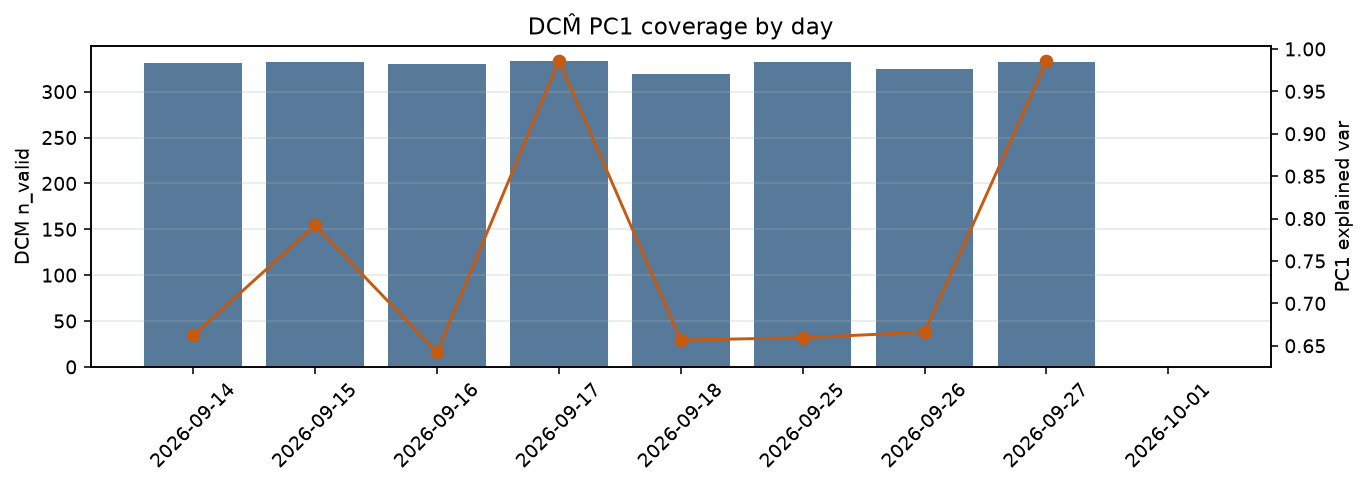

In [3]:
show_pngs(OUT / "dcm_proxies" / "figs")


## Expansion — loadings heatmap + explained variance


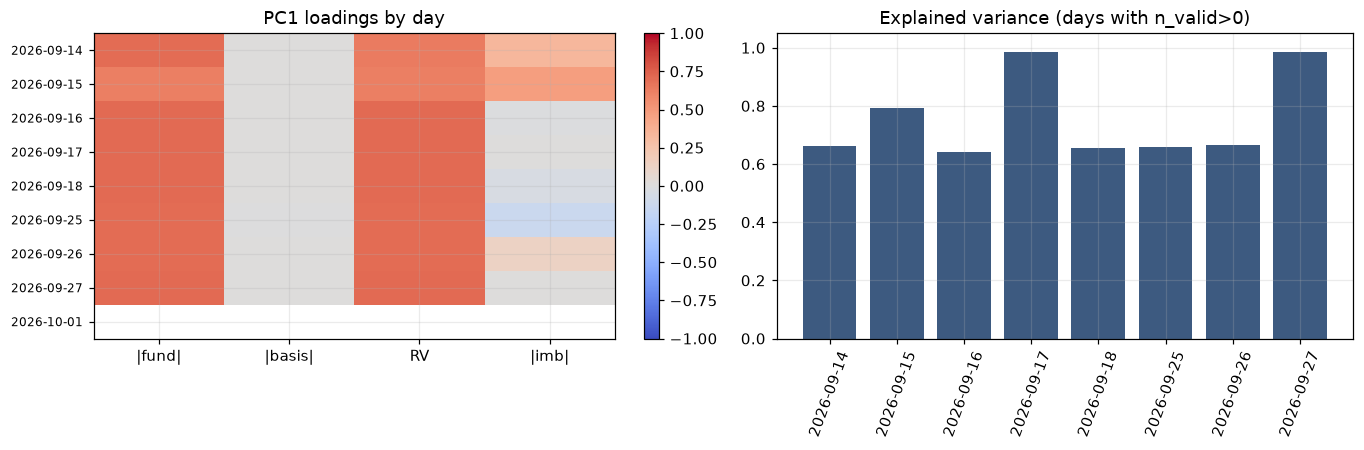

basis loading near-zero days: 8


In [4]:

keys = ["L_abs_funding","L_abs_basis","L_rv","L_abs_imbalance"]
mat = load_df.set_index("day")[keys]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
im = ax.imshow(mat.values.astype(float), aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(list(mat.index), fontsize=8)
ax.set_xticks(range(len(keys))); ax.set_xticklabels(["|fund|","|basis|","RV","|imb|"], rotation=0)
ax.set_title("PC1 loadings by day")
fig.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1]
valid = load_df[load_df["n_valid"].fillna(0) > 0]
ax.bar(valid["day"], valid["explained"], color="#3d5a80")
ax.tick_params(axis="x", rotation=70)
ax.set_ylim(0, 1.05); ax.set_title("Explained variance (days with n_valid>0)")
plt.tight_layout(); plt.show()
print("basis loading near-zero days:", int((load_df["L_abs_basis"].abs() < 1e-8).sum()))


## Expansion — hourly DCM̂ vs PIM (joined days)


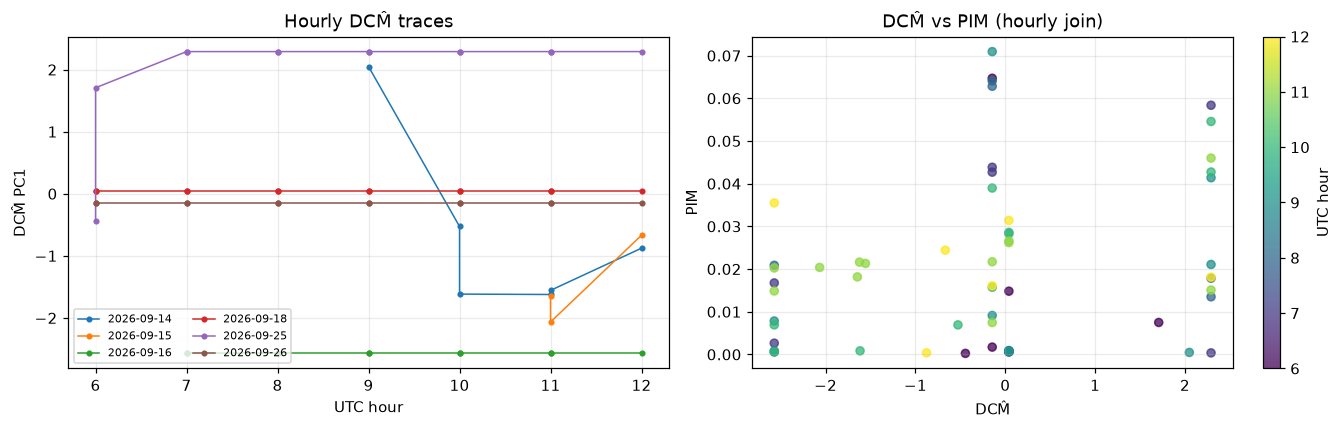

corr(DCM,PIM) 0.24841796234971172 n 59


In [5]:

ok = hourly[np.isfinite(hourly["dcm"]) & np.isfinite(hourly["pim"])].copy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
ax = axes[0]
for day, g in ok.groupby("day"):
    ax.plot(g["hour_utc"], g["dcm"], marker="o", ms=3, lw=1, label=day)
ax.set_xlabel("UTC hour"); ax.set_ylabel("DCM̂ PC1"); ax.set_title("Hourly DCM̂ traces")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
sc = ax.scatter(ok["dcm"], ok["pim"], c=ok["hour_utc"], cmap="viridis", s=28, alpha=0.75)
ax.set_xlabel("DCM̂"); ax.set_ylabel("PIM"); ax.set_title("DCM̂ vs PIM (hourly join)")
fig.colorbar(sc, ax=ax, label="UTC hour")
plt.tight_layout(); plt.show()
print("corr(DCM,PIM)", float(ok["dcm"].corr(ok["pim"])) if len(ok)>2 else None, "n", len(ok))


## Signal board


In [6]:

print_board([
    ("risk.dcm_pc1", "Hold", "PC1 usable on most days; unstable when only funding+RV load"),
    ("risk.bank_cds_var", "Kill", "no public crypto CDS/VaR analogue"),
])
print("Falsifier: PC stability across days + placebo DCM shuffle → Pass-2")


id                                 gate   note
----------------------------------------------------------------------------------------
risk.dcm_pc1                       Hold   PC1 usable on most days; unstable when only funding+RV load
risk.bank_cds_var                  Kill   no public crypto CDS/VaR analogue
Falsifier: PC stability across days + placebo DCM shuffle → Pass-2
